In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("synthetic_asthma_dataset.csv")
df

,Patient_ID,Age,Gender,BMI,Smoking_Status,Family_History,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level
0,ASTH100000,52,Female,27.6,Former,1,NaN,Moderate,Sedentary,Outdoor,Diabetes,0.38,0,421.0,46.0,0,NaN
1,ASTH100001,15,Male,24.6,Former,0,Dust,Low,Moderate,Indoor,Both,0.60,2,297.6,22.9,0,NaN
2,ASTH100002,72,Female,17.6,Never,0,NaN,Moderate,Moderate,Indoor,NaN,0.38,0,303.3,15.3,0,NaN
3,ASTH100003,61,Male,16.8,Never,0,Multiple,High,Sedentary,Outdoor,Both,0.60,1,438.0,40.1,1,Poorly Controlled
4,ASTH100004,21,Male,30.2,Never,0,NaN,Moderate,Active,Indoor,NaN,0.82,3,535.0,27.7,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ASTH109995,70,Male,25.0,Never,0,NaN,Low,Sedentary,Indoor,NaN,0.67,0,580.6,18.7,0,NaN
9996,ASTH109996,78,Female,24.8,Never,0,Pollen,Low,Moderate,Indoor,Diabetes,0.72,1,417.6,40.8,0,NaN
9997,ASTH109997,58,Male,30.1,Former,1,Pollen,Low,Moderate,Indoor,NaN,0.28,0,459.1,20.3,1,Not Controlled
9998,ASTH109998,88,Female,31.2,Former,0,Pollen,Moderate,Moderate,Indoor,NaN,0.44,0,415.9,25.0,0,NaN


In [3]:
#data inspection
print(df.shape)

(10000, 17)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               10000 non-null  object 
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   BMI                      10000 non-null  float64
 4   Smoking_Status           10000 non-null  object 
 5   Family_History           10000 non-null  int64  
 6   Allergies                7064 non-null   object 
 7   Air_Pollution_Level      10000 non-null  object 
 8   Physical_Activity_Level  10000 non-null  object 
 9   Occupation_Type          10000 non-null  object 
 10  Comorbidities            5033 non-null   object 
 11  Medication_Adherence     10000 non-null  float64
 12  Number_of_ER_Visits      10000 non-null  int64  
 13  Peak_Expiratory_Flow     10000 non-null  float64
 14  FeNO_Level             

In [5]:
print(df.describe())

                Age           BMI  Family_History  Medication_Adherence  \
count  10000.000000  10000.000000    10000.000000          10000.000000   
mean      44.930700     25.053320        0.303400              0.497998   
std       25.653559      4.874466        0.459749              0.224809   
min        1.000000     15.000000        0.000000              0.000000   
25%       23.000000     21.600000        0.000000              0.320000   
50%       45.000000     25.000000        0.000000              0.500000   
75%       67.000000     28.400000        1.000000              0.670000   
max       89.000000     45.000000        1.000000              0.990000   

       Number_of_ER_Visits  Peak_Expiratory_Flow    FeNO_Level    Has_Asthma  
count         10000.000000          10000.000000  10000.000000  10000.000000  
mean              1.015900            400.884090     25.101420      0.243300  
std               1.020564             97.531113      9.840184      0.429096  
min     

In [6]:
#checking for null values
print(df.isna().sum())

Patient_ID                    0
Age                           0
Gender                        0
BMI                           0
Smoking_Status                0
Family_History                0
Allergies                  2936
Air_Pollution_Level           0
Physical_Activity_Level       0
Occupation_Type               0
Comorbidities              4967
Medication_Adherence          0
Number_of_ER_Visits           0
Peak_Expiratory_Flow          0
FeNO_Level                    0
Has_Asthma                    0
Asthma_Control_Level       7567
dtype: int64


In [7]:
df['Allergies'].fillna(df['Allergies'].ffill(),inplace=True)
df

/tmp/ipykernel_438/3764512599.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Allergies'].fillna(df['Allergies'].ffill(),inplace=True)


,Patient_ID,Age,Gender,BMI,Smoking_Status,Family_History,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level
0,ASTH100000,52,Female,27.6,Former,1,NaN,Moderate,Sedentary,Outdoor,Diabetes,0.38,0,421.0,46.0,0,NaN
1,ASTH100001,15,Male,24.6,Former,0,Dust,Low,Moderate,Indoor,Both,0.60,2,297.6,22.9,0,NaN
2,ASTH100002,72,Female,17.6,Never,0,Dust,Moderate,Moderate,Indoor,NaN,0.38,0,303.3,15.3,0,NaN
3,ASTH100003,61,Male,16.8,Never,0,Multiple,High,Sedentary,Outdoor,Both,0.60,1,438.0,40.1,1,Poorly Controlled
4,ASTH100004,21,Male,30.2,Never,0,Multiple,Moderate,Active,Indoor,NaN,0.82,3,535.0,27.7,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ASTH109995,70,Male,25.0,Never,0,Dust,Low,Sedentary,Indoor,NaN,0.67,0,580.6,18.7,0,NaN
9996,ASTH109996,78,Female,24.8,Never,0,Pollen,Low,Moderate,Indoor,Diabetes,0.72,1,417.6,40.8,0,NaN
9997,ASTH109997,58,Male,30.1,Former,1,Pollen,Low,Moderate,Indoor,NaN,0.28,0,459.1,20.3,1,Not Controlled
9998,ASTH109998,88,Female,31.2,Former,0,Pollen,Moderate,Moderate,Indoor,NaN,0.44,0,415.9,25.0,0,NaN


In [8]:
df['Comorbidities'].fillna(df['Comorbidities'].ffill(),inplace=True)
df

/tmp/ipykernel_438/60946780.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Comorbidities'].fillna(df['Comorbidities'].ffill(),inplace=True)


,Patient_ID,Age,Gender,BMI,Smoking_Status,Family_History,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level
0,ASTH100000,52,Female,27.6,Former,1,NaN,Moderate,Sedentary,Outdoor,Diabetes,0.38,0,421.0,46.0,0,NaN
1,ASTH100001,15,Male,24.6,Former,0,Dust,Low,Moderate,Indoor,Both,0.60,2,297.6,22.9,0,NaN
2,ASTH100002,72,Female,17.6,Never,0,Dust,Moderate,Moderate,Indoor,Both,0.38,0,303.3,15.3,0,NaN
3,ASTH100003,61,Male,16.8,Never,0,Multiple,High,Sedentary,Outdoor,Both,0.60,1,438.0,40.1,1,Poorly Controlled
4,ASTH100004,21,Male,30.2,Never,0,Multiple,Moderate,Active,Indoor,Both,0.82,3,535.0,27.7,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ASTH109995,70,Male,25.0,Never,0,Dust,Low,Sedentary,Indoor,Hypertension,0.67,0,580.6,18.7,0,NaN
9996,ASTH109996,78,Female,24.8,Never,0,Pollen,Low,Moderate,Indoor,Diabetes,0.72,1,417.6,40.8,0,NaN
9997,ASTH109997,58,Male,30.1,Former,1,Pollen,Low,Moderate,Indoor,Diabetes,0.28,0,459.1,20.3,1,Not Controlled
9998,ASTH109998,88,Female,31.2,Former,0,Pollen,Moderate,Moderate,Indoor,Diabetes,0.44,0,415.9,25.0,0,NaN


In [9]:
df['Asthma_Control_Level'].fillna(df['Asthma_Control_Level'].bfill(),inplace=True)
df

/tmp/ipykernel_438/3522532365.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Asthma_Control_Level'].fillna(df['Asthma_Control_Level'].bfill(),inplace=True)


,Patient_ID,Age,Gender,BMI,Smoking_Status,Family_History,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level
0,ASTH100000,52,Female,27.6,Former,1,NaN,Moderate,Sedentary,Outdoor,Diabetes,0.38,0,421.0,46.0,0,Poorly Controlled
1,ASTH100001,15,Male,24.6,Former,0,Dust,Low,Moderate,Indoor,Both,0.60,2,297.6,22.9,0,Poorly Controlled
2,ASTH100002,72,Female,17.6,Never,0,Dust,Moderate,Moderate,Indoor,Both,0.38,0,303.3,15.3,0,Poorly Controlled
3,ASTH100003,61,Male,16.8,Never,0,Multiple,High,Sedentary,Outdoor,Both,0.60,1,438.0,40.1,1,Poorly Controlled
4,ASTH100004,21,Male,30.2,Never,0,Multiple,Moderate,Active,Indoor,Both,0.82,3,535.0,27.7,0,Poorly Controlled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ASTH109995,70,Male,25.0,Never,0,Dust,Low,Sedentary,Indoor,Hypertension,0.67,0,580.6,18.7,0,Not Controlled
9996,ASTH109996,78,Female,24.8,Never,0,Pollen,Low,Moderate,Indoor,Diabetes,0.72,1,417.6,40.8,0,Not Controlled
9997,ASTH109997,58,Male,30.1,Former,1,Pollen,Low,Moderate,Indoor,Diabetes,0.28,0,459.1,20.3,1,Not Controlled
9998,ASTH109998,88,Female,31.2,Former,0,Pollen,Moderate,Moderate,Indoor,Diabetes,0.44,0,415.9,25.0,0,Not Controlled


In [10]:
print(df.isna().sum())

Patient_ID                 0
Age                        0
Gender                     0
BMI                        0
Smoking_Status             0
Family_History             0
Allergies                  1
Air_Pollution_Level        0
Physical_Activity_Level    0
Occupation_Type            0
Comorbidities              0
Medication_Adherence       0
Number_of_ER_Visits        0
Peak_Expiratory_Flow       0
FeNO_Level                 0
Has_Asthma                 0
Asthma_Control_Level       0
dtype: int64


Smoking_Status
Never      6070
Former     2487
Current    1443
Name: count, dtype: int64


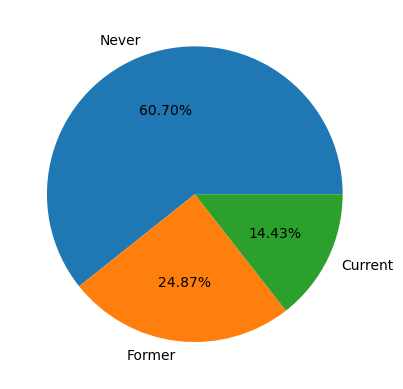

In [11]:
#visualization
#patient wise diffrent smoking status
smoke=df['Smoking_Status'].value_counts()
print(smoke)
x=smoke.index
y=smoke.values
plt.pie(y,labels=x,autopct='%1.2f%%')
plt.show()

Gender
Female    4814
Male      4786
Other      400
Name: count, dtype: int64


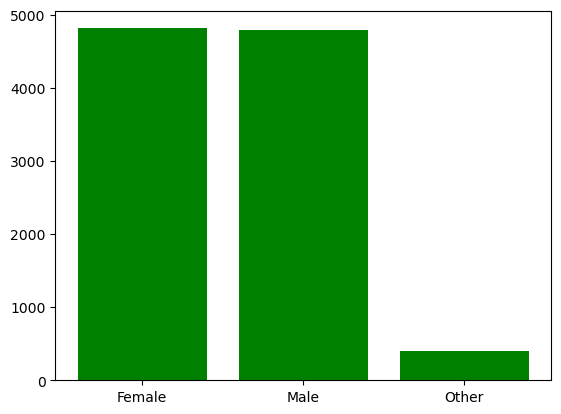

In [12]:
#patient based on gender
g=df['Gender'].value_counts()
print(g)
a=g.index
b=g.values
plt.bar(a,b,color='g')
plt.show()

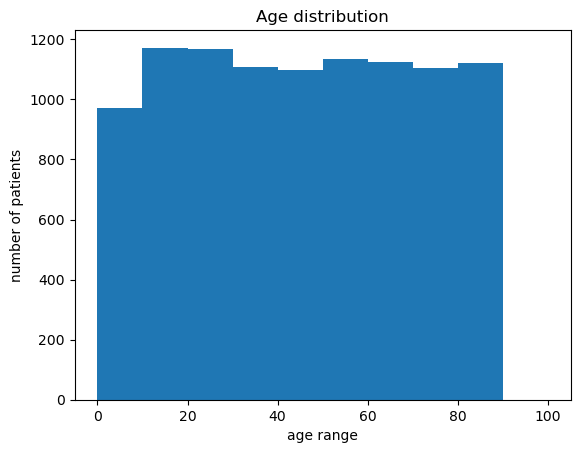

In [13]:
#age distribution
x=df['Age']
k=[0,10,20,30,40,50,60,70,80,90,100]
plt.hist(x,bins=k)
plt.title('Age distribution')
plt.xlabel('age range')
plt.ylabel('number of patients')
plt.show()

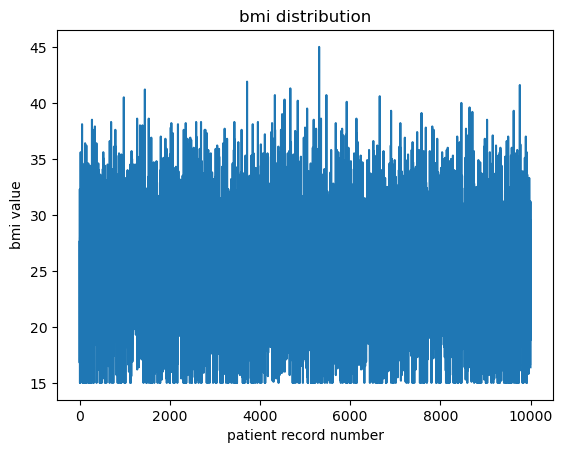

In [14]:
#bmi distribution
a=df.iloc[:100]
b=df['BMI']
plt.plot(b)
plt.title('bmi distribution')
plt.xlabel('patient record number')
plt.ylabel('bmi value')
plt.show()


In [15]:
#removing unnecessary columns
#df.drop('id',axis=1,inplace=True)
df.drop(['Patient_ID','Family_History'],axis=1,inplace=True)
df

,Age,Gender,BMI,Smoking_Status,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level
0,52,Female,27.6,Former,NaN,Moderate,Sedentary,Outdoor,Diabetes,0.38,0,421.0,46.0,0,Poorly Controlled
1,15,Male,24.6,Former,Dust,Low,Moderate,Indoor,Both,0.60,2,297.6,22.9,0,Poorly Controlled
2,72,Female,17.6,Never,Dust,Moderate,Moderate,Indoor,Both,0.38,0,303.3,15.3,0,Poorly Controlled
3,61,Male,16.8,Never,Multiple,High,Sedentary,Outdoor,Both,0.60,1,438.0,40.1,1,Poorly Controlled
4,21,Male,30.2,Never,Multiple,Moderate,Active,Indoor,Both,0.82,3,535.0,27.7,0,Poorly Controlled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,70,Male,25.0,Never,Dust,Low,Sedentary,Indoor,Hypertension,0.67,0,580.6,18.7,0,Not Controlled
9996,78,Female,24.8,Never,Pollen,Low,Moderate,Indoor,Diabetes,0.72,1,417.6,40.8,0,Not Controlled
9997,58,Male,30.1,Former,Pollen,Low,Moderate,Indoor,Diabetes,0.28,0,459.1,20.3,1,Not Controlled
9998,88,Female,31.2,Former,Pollen,Moderate,Moderate,Indoor,Diabetes,0.44,0,415.9,25.0,0,Not Controlled


In [16]:
#encoding 
#gender mapping
df['Gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [17]:
df['Gender']=df['Gender'].map({'Male':0,'Female':1,'Other':2})
df

,Age,Gender,BMI,Smoking_Status,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level
0,52,1,27.6,Former,NaN,Moderate,Sedentary,Outdoor,Diabetes,0.38,0,421.0,46.0,0,Poorly Controlled
1,15,0,24.6,Former,Dust,Low,Moderate,Indoor,Both,0.60,2,297.6,22.9,0,Poorly Controlled
2,72,1,17.6,Never,Dust,Moderate,Moderate,Indoor,Both,0.38,0,303.3,15.3,0,Poorly Controlled
3,61,0,16.8,Never,Multiple,High,Sedentary,Outdoor,Both,0.60,1,438.0,40.1,1,Poorly Controlled
4,21,0,30.2,Never,Multiple,Moderate,Active,Indoor,Both,0.82,3,535.0,27.7,0,Poorly Controlled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,70,0,25.0,Never,Dust,Low,Sedentary,Indoor,Hypertension,0.67,0,580.6,18.7,0,Not Controlled
9996,78,1,24.8,Never,Pollen,Low,Moderate,Indoor,Diabetes,0.72,1,417.6,40.8,0,Not Controlled
9997,58,0,30.1,Former,Pollen,Low,Moderate,Indoor,Diabetes,0.28,0,459.1,20.3,1,Not Controlled
9998,88,1,31.2,Former,Pollen,Moderate,Moderate,Indoor,Diabetes,0.44,0,415.9,25.0,0,Not Controlled


In [18]:
#occupation type-dummy encoding
df=pd.get_dummies(df,columns=['Occupation_Type'],dtype='int')
df

,Age,Gender,BMI,Smoking_Status,Allergies,Air_Pollution_Level,Physical_Activity_Level,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level,Occupation_Type_Indoor,Occupation_Type_Outdoor
0,52,1,27.6,Former,NaN,Moderate,Sedentary,Diabetes,0.38,0,421.0,46.0,0,Poorly Controlled,0,1
1,15,0,24.6,Former,Dust,Low,Moderate,Both,0.60,2,297.6,22.9,0,Poorly Controlled,1,0
2,72,1,17.6,Never,Dust,Moderate,Moderate,Both,0.38,0,303.3,15.3,0,Poorly Controlled,1,0
3,61,0,16.8,Never,Multiple,High,Sedentary,Both,0.60,1,438.0,40.1,1,Poorly Controlled,0,1
4,21,0,30.2,Never,Multiple,Moderate,Active,Both,0.82,3,535.0,27.7,0,Poorly Controlled,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,70,0,25.0,Never,Dust,Low,Sedentary,Hypertension,0.67,0,580.6,18.7,0,Not Controlled,1,0
9996,78,1,24.8,Never,Pollen,Low,Moderate,Diabetes,0.72,1,417.6,40.8,0,Not Controlled,1,0
9997,58,0,30.1,Former,Pollen,Low,Moderate,Diabetes,0.28,0,459.1,20.3,1,Not Controlled,1,0
9998,88,1,31.2,Former,Pollen,Moderate,Moderate,Diabetes,0.44,0,415.9,25.0,0,Not Controlled,1,0


In [19]:
#smoking status type-dummy encoding
df=pd.get_dummies(df,columns=['Smoking_Status'],dtype='int')
df

,Age,Gender,BMI,Allergies,Air_Pollution_Level,Physical_Activity_Level,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level,Occupation_Type_Indoor,Occupation_Type_Outdoor,Smoking_Status_Current,Smoking_Status_Former,Smoking_Status_Never
0,52,1,27.6,NaN,Moderate,Sedentary,Diabetes,0.38,0,421.0,46.0,0,Poorly Controlled,0,1,0,1,0
1,15,0,24.6,Dust,Low,Moderate,Both,0.60,2,297.6,22.9,0,Poorly Controlled,1,0,0,1,0
2,72,1,17.6,Dust,Moderate,Moderate,Both,0.38,0,303.3,15.3,0,Poorly Controlled,1,0,0,0,1
3,61,0,16.8,Multiple,High,Sedentary,Both,0.60,1,438.0,40.1,1,Poorly Controlled,0,1,0,0,1
4,21,0,30.2,Multiple,Moderate,Active,Both,0.82,3,535.0,27.7,0,Poorly Controlled,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,70,0,25.0,Dust,Low,Sedentary,Hypertension,0.67,0,580.6,18.7,0,Not Controlled,1,0,0,0,1
9996,78,1,24.8,Pollen,Low,Moderate,Diabetes,0.72,1,417.6,40.8,0,Not Controlled,1,0,0,0,1
9997,58,0,30.1,Pollen,Low,Moderate,Diabetes,0.28,0,459.1,20.3,1,Not Controlled,1,0,0,1,0
9998,88,1,31.2,Pollen,Moderate,Moderate,Diabetes,0.44,0,415.9,25.0,0,Not Controlled,1,0,0,1,0


In [20]:
#physical activity level-dummy encoding
df=pd.get_dummies(df,columns=['Physical_Activity_Level'],dtype='int')
df

,Age,Gender,BMI,Allergies,Air_Pollution_Level,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level,Occupation_Type_Indoor,Occupation_Type_Outdoor,Smoking_Status_Current,Smoking_Status_Former,Smoking_Status_Never,Physical_Activity_Level_Active,Physical_Activity_Level_Moderate,Physical_Activity_Level_Sedentary
0,52,1,27.6,NaN,Moderate,Diabetes,0.38,0,421.0,46.0,0,Poorly Controlled,0,1,0,1,0,0,0,1
1,15,0,24.6,Dust,Low,Both,0.60,2,297.6,22.9,0,Poorly Controlled,1,0,0,1,0,0,1,0
2,72,1,17.6,Dust,Moderate,Both,0.38,0,303.3,15.3,0,Poorly Controlled,1,0,0,0,1,0,1,0
3,61,0,16.8,Multiple,High,Both,0.60,1,438.0,40.1,1,Poorly Controlled,0,1,0,0,1,0,0,1
4,21,0,30.2,Multiple,Moderate,Both,0.82,3,535.0,27.7,0,Poorly Controlled,1,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,70,0,25.0,Dust,Low,Hypertension,0.67,0,580.6,18.7,0,Not Controlled,1,0,0,0,1,0,0,1
9996,78,1,24.8,Pollen,Low,Diabetes,0.72,1,417.6,40.8,0,Not Controlled,1,0,0,0,1,0,1,0
9997,58,0,30.1,Pollen,Low,Diabetes,0.28,0,459.1,20.3,1,Not Controlled,1,0,0,1,0,0,1,0
9998,88,1,31.2,Pollen,Moderate,Diabetes,0.44,0,415.9,25.0,0,Not Controlled,1,0,0,1,0,0,1,0


In [21]:
#allergies-dummy encoding
df=pd.get_dummies(df,columns=['Allergies'],dtype='int')
df

,Age,Gender,BMI,Air_Pollution_Level,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,...,Smoking_Status_Current,Smoking_Status_Former,Smoking_Status_Never,Physical_Activity_Level_Active,Physical_Activity_Level_Moderate,Physical_Activity_Level_Sedentary,Allergies_Dust,Allergies_Multiple,Allergies_Pets,Allergies_Pollen
0,52,1,27.6,Moderate,Diabetes,0.38,0,421.0,46.0,0,...,0,1,0,0,0,1,0,0,0,0
1,15,0,24.6,Low,Both,0.60,2,297.6,22.9,0,...,0,1,0,0,1,0,1,0,0,0
2,72,1,17.6,Moderate,Both,0.38,0,303.3,15.3,0,...,0,0,1,0,1,0,1,0,0,0
3,61,0,16.8,High,Both,0.60,1,438.0,40.1,1,...,0,0,1,0,0,1,0,1,0,0
4,21,0,30.2,Moderate,Both,0.82,3,535.0,27.7,0,...,0,0,1,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,70,0,25.0,Low,Hypertension,0.67,0,580.6,18.7,0,...,0,0,1,0,0,1,1,0,0,0
9996,78,1,24.8,Low,Diabetes,0.72,1,417.6,40.8,0,...,0,0,1,0,1,0,0,0,0,1
9997,58,0,30.1,Low,Diabetes,0.28,0,459.1,20.3,1,...,0,1,0,0,1,0,0,0,0,1
9998,88,1,31.2,Moderate,Diabetes,0.44,0,415.9,25.0,0,...,0,1,0,0,1,0,0,0,0,1


In [22]:
#air pollution level-dummy encoding
df=pd.get_dummies(df,columns=['Air_Pollution_Level'],dtype='int')
df

,Age,Gender,BMI,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level,...,Physical_Activity_Level_Active,Physical_Activity_Level_Moderate,Physical_Activity_Level_Sedentary,Allergies_Dust,Allergies_Multiple,Allergies_Pets,Allergies_Pollen,Air_Pollution_Level_High,Air_Pollution_Level_Low,Air_Pollution_Level_Moderate
0,52,1,27.6,Diabetes,0.38,0,421.0,46.0,0,Poorly Controlled,...,0,0,1,0,0,0,0,0,0,1
1,15,0,24.6,Both,0.60,2,297.6,22.9,0,Poorly Controlled,...,0,1,0,1,0,0,0,0,1,0
2,72,1,17.6,Both,0.38,0,303.3,15.3,0,Poorly Controlled,...,0,1,0,1,0,0,0,0,0,1
3,61,0,16.8,Both,0.60,1,438.0,40.1,1,Poorly Controlled,...,0,0,1,0,1,0,0,1,0,0
4,21,0,30.2,Both,0.82,3,535.0,27.7,0,Poorly Controlled,...,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,70,0,25.0,Hypertension,0.67,0,580.6,18.7,0,Not Controlled,...,0,0,1,1,0,0,0,0,1,0
9996,78,1,24.8,Diabetes,0.72,1,417.6,40.8,0,Not Controlled,...,0,1,0,0,0,0,1,0,1,0
9997,58,0,30.1,Diabetes,0.28,0,459.1,20.3,1,Not Controlled,...,0,1,0,0,0,0,1,0,1,0
9998,88,1,31.2,Diabetes,0.44,0,415.9,25.0,0,Not Controlled,...,0,1,0,0,0,0,1,0,0,1


In [23]:
#Comorbidities-dummy encoding
df=pd.get_dummies(df,columns=['Comorbidities'],dtype='int')
df

,Age,Gender,BMI,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level,Occupation_Type_Indoor,...,Allergies_Dust,Allergies_Multiple,Allergies_Pets,Allergies_Pollen,Air_Pollution_Level_High,Air_Pollution_Level_Low,Air_Pollution_Level_Moderate,Comorbidities_Both,Comorbidities_Diabetes,Comorbidities_Hypertension
0,52,1,27.6,0.38,0,421.0,46.0,0,Poorly Controlled,0,...,0,0,0,0,0,0,1,0,1,0
1,15,0,24.6,0.60,2,297.6,22.9,0,Poorly Controlled,1,...,1,0,0,0,0,1,0,1,0,0
2,72,1,17.6,0.38,0,303.3,15.3,0,Poorly Controlled,1,...,1,0,0,0,0,0,1,1,0,0
3,61,0,16.8,0.60,1,438.0,40.1,1,Poorly Controlled,0,...,0,1,0,0,1,0,0,1,0,0
4,21,0,30.2,0.82,3,535.0,27.7,0,Poorly Controlled,1,...,0,1,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,70,0,25.0,0.67,0,580.6,18.7,0,Not Controlled,1,...,1,0,0,0,0,1,0,0,0,1
9996,78,1,24.8,0.72,1,417.6,40.8,0,Not Controlled,1,...,0,0,0,1,0,1,0,0,1,0
9997,58,0,30.1,0.28,0,459.1,20.3,1,Not Controlled,1,...,0,0,0,1,0,1,0,0,1,0
9998,88,1,31.2,0.44,0,415.9,25.0,0,Not Controlled,1,...,0,0,0,1,0,0,1,0,1,0


In [24]:
#Asthma_Control_Level-dummy encoding
df=pd.get_dummies(df,columns=['Asthma_Control_Level'],dtype='int')
df

,Age,Gender,BMI,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Occupation_Type_Indoor,Occupation_Type_Outdoor,...,Allergies_Pollen,Air_Pollution_Level_High,Air_Pollution_Level_Low,Air_Pollution_Level_Moderate,Comorbidities_Both,Comorbidities_Diabetes,Comorbidities_Hypertension,Asthma_Control_Level_Not Controlled,Asthma_Control_Level_Poorly Controlled,Asthma_Control_Level_Well Controlled
0,52,1,27.6,0.38,0,421.0,46.0,0,0,1,...,0,0,0,1,0,1,0,0,1,0
1,15,0,24.6,0.60,2,297.6,22.9,0,1,0,...,0,0,1,0,1,0,0,0,1,0
2,72,1,17.6,0.38,0,303.3,15.3,0,1,0,...,0,0,0,1,1,0,0,0,1,0
3,61,0,16.8,0.60,1,438.0,40.1,1,0,1,...,0,1,0,0,1,0,0,0,1,0
4,21,0,30.2,0.82,3,535.0,27.7,0,1,0,...,0,0,0,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,70,0,25.0,0.67,0,580.6,18.7,0,1,0,...,0,0,1,0,0,0,1,1,0,0
9996,78,1,24.8,0.72,1,417.6,40.8,0,1,0,...,1,0,1,0,0,1,0,1,0,0
9997,58,0,30.1,0.28,0,459.1,20.3,1,1,0,...,1,0,1,0,0,1,0,1,0,0
9998,88,1,31.2,0.44,0,415.9,25.0,0,1,0,...,1,0,0,1,0,1,0,1,0,0


In [25]:
df.shape

(10000, 29)

In [26]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Medication_Adherence', 'Number_of_ER_Visits',
       'Peak_Expiratory_Flow', 'FeNO_Level', 'Has_Asthma',
       'Occupation_Type_Indoor', 'Occupation_Type_Outdoor',
       'Smoking_Status_Current', 'Smoking_Status_Former',
       'Smoking_Status_Never', 'Physical_Activity_Level_Active',
       'Physical_Activity_Level_Moderate', 'Physical_Activity_Level_Sedentary',
       'Allergies_Dust', 'Allergies_Multiple', 'Allergies_Pets',
       'Allergies_Pollen', 'Air_Pollution_Level_High',
       'Air_Pollution_Level_Low', 'Air_Pollution_Level_Moderate',
       'Comorbidities_Both', 'Comorbidities_Diabetes',
       'Comorbidities_Hypertension', 'Asthma_Control_Level_Not Controlled',
       'Asthma_Control_Level_Poorly Controlled',
       'Asthma_Control_Level_Well Controlled'],
      dtype='object')

In [27]:
#data labelling
x=df.drop('Has_Asthma',axis=1)
y=df['Has_Asthma']

In [28]:
#splitting the data for training and testing
#x_Train(80% x),x_test(20% x),y_train(80% y),y_test(20% y)

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [30]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 28)
(2000, 28)
(8000,)
(2000,)


In [31]:
#algorithms classification
#logistic regression
#decision tree
#random forest
#support vector machine
#native bayes

In [32]:
#logistic regression
#1.import algorithm,
from sklearn.linear_model import LogisticRegression

#2.object for class
#model
lr=LogisticRegression()

In [33]:
#model training
lr.fit(x_train,y_train)
print(lr)

LogisticRegression()


/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
#model testing
result=lr.predict(x_test)
print(result)

[0 1 0 ... 0 0 0]


In [35]:
#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
score = accuracy_score(y_test, result)
print('Accuracy score of the LR model:', score)

# Classification report
cr = classification_report(y_test, result)
print('Classification Report:\n', cr)

Accuracy score of the LR model: 0.8535
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.91      1504
           1       0.82      0.53      0.64       496

    accuracy                           0.85      2000
   macro avg       0.84      0.74      0.77      2000
weighted avg       0.85      0.85      0.84      2000



Confusion Matrix:
 [[1446   58]
 [ 235  261]]


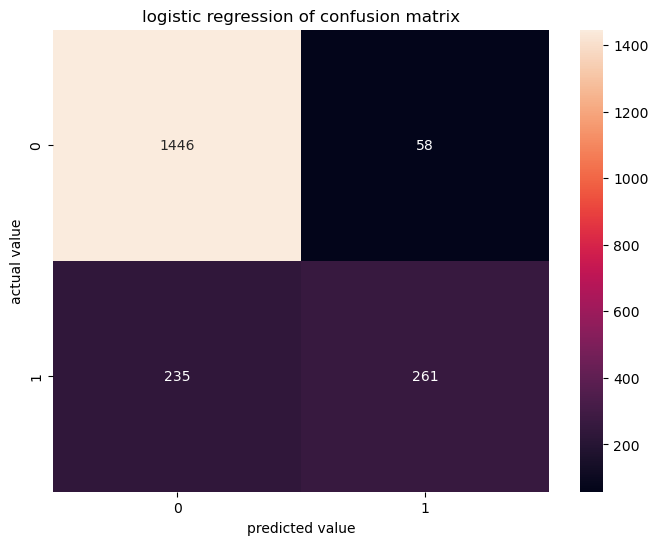

In [36]:
# Confusion matrix
import seaborn as sns
cm = confusion_matrix(y_test, result)
print('Confusion Matrix:\n', cm)

plt.figure(figsize=(8,6),dpi=100)
plt.title("logistic regression of confusion matrix")

sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("predicted value")
plt.ylabel("actual value")
plt.show()

In [37]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
#model building
dt=DecisionTreeClassifier()
#model training
dt.fit(x_train,y_train)
#model testing
result_dt=dt.predict(x_test)
print(result_dt)

[0 1 1 ... 0 0 0]


In [38]:
#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Calculate accuracy
score_dt = accuracy_score(y_test, result)
print('Accuracy score of the LR model:', score_dt)

# Classification report
cr_dt = classification_report(y_test, result_dt)
print('Classification Report:\n', cr_dt)

Accuracy score of the LR model: 0.8535
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.86      0.86      1504
           1       0.59      0.62      0.60       496

    accuracy                           0.80      2000
   macro avg       0.73      0.74      0.73      2000
weighted avg       0.80      0.80      0.80      2000



Confusion Matrix:
 [[1290  214]
 [ 190  306]]


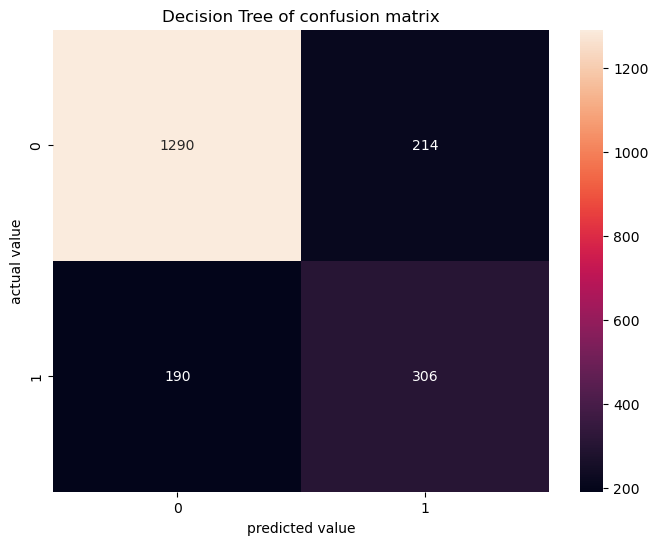

In [39]:
# Confusion matrix
import seaborn as sns
cm_dt = confusion_matrix(y_test, result_dt)
print('Confusion Matrix:\n', cm_dt)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Decision Tree of confusion matrix")

sns.heatmap(cm_dt,annot=True,fmt='d')
plt.xlabel("predicted value")
plt.ylabel("actual value")
plt.show()


In [40]:
#random forest
from sklearn.ensemble import RandomForestClassifier

#model building
rf=RandomForestClassifier()

#model training
dt.fit(x_train,y_train)

#model testing
result_rf=dt.predict(x_test)
print(result_rf)

[0 1 0 ... 0 0 0]


In [41]:
#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Calculate accuracy
score_rf = accuracy_score(y_test, result)
print('Accuracy score of the LR model:', score_rf)

# Classification report
cr_rf = classification_report(y_test, result_rf)
print('Classification Report:\n', cr_rf)

Accuracy score of the LR model: 0.8535
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.86      0.86      1504
           1       0.59      0.62      0.60       496

    accuracy                           0.80      2000
   macro avg       0.73      0.74      0.73      2000
weighted avg       0.80      0.80      0.80      2000



Confusion Matrix:
 [[1289  215]
 [ 189  307]]


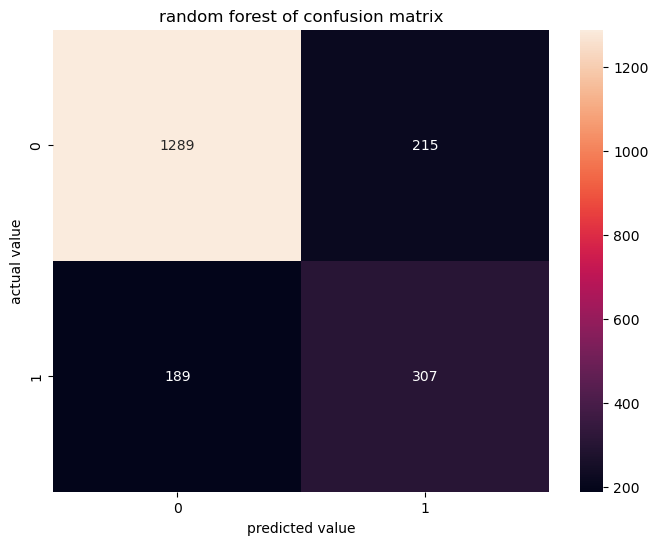

In [42]:
# Confusion matrix
import seaborn as sns
cm_rf = confusion_matrix(y_test, result_rf)
print('Confusion Matrix:\n', cm_rf)

plt.figure(figsize=(8,6),dpi=100)
plt.title("random forest of confusion matrix")

sns.heatmap(cm_rf,annot=True,fmt='d')
plt.xlabel("predicted value")
plt.ylabel("actual value")
plt.show()

[0 1 0 ... 0 0 0]
Accuracy score of the LR model: 0.8535
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.86      0.86      1504
           1       0.59      0.62      0.60       496

    accuracy                           0.80      2000
   macro avg       0.73      0.74      0.73      2000
weighted avg       0.80      0.80      0.80      2000

Confusion Matrix:
 [[1289  215]
 [ 189  307]]


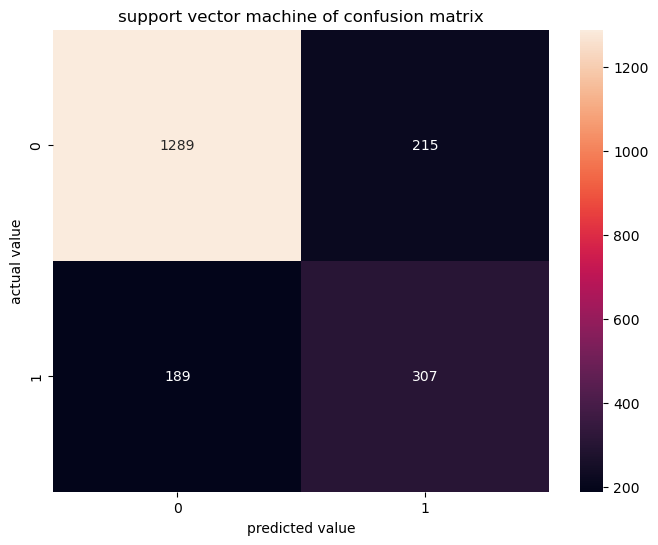

In [43]:
#4.support vector machine
from sklearn.svm import SVC
#model building
svc=SVC()
#model training
svc.fit(x_train,y_train)

#model testing
result_svc=dt.predict(x_test)
print(result_svc)

#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Calculate accuracy
score_svc = accuracy_score(y_test, result)
print('Accuracy score of the LR model:', score_svc)

# Classification report
cr_svc= classification_report(y_test, result_rf)
print('Classification Report:\n', cr_svc)

# Confusion matrix
import seaborn as sns
cm_svc = confusion_matrix(y_test, result_rf)
print('Confusion Matrix:\n', cm_svc)

plt.figure(figsize=(8,6),dpi=100)
plt.title("support vector machine of confusion matrix")

sns.heatmap(cm_svc,annot=True,fmt='d')
plt.xlabel("predicted value")
plt.ylabel("actual value")
plt.show()

In [44]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [45]:
print(y_test.unique())
print(y_train.value_counts())

[0 1]
Has_Asthma
0    6063
1    1937
Name: count, dtype: int64


In [46]:
#oversampling method of balance
from imblearn.over_sampling import SMOTE
smt=SMOTE()
x_train_sampled,y_train_sampled=smt.fit_resample(x_train,y_train)

/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


LogisticRegression()
[0 1 0 ... 0 0 0]
Accuracy score of the LR model: 0.7695
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.77      0.83      1504
           1       0.52      0.76      0.62       496

    accuracy                           0.77      2000
   macro avg       0.72      0.77      0.73      2000
weighted avg       0.81      0.77      0.78      2000

Confusion Matrix:
 [[1162  342]
 [ 119  377]]


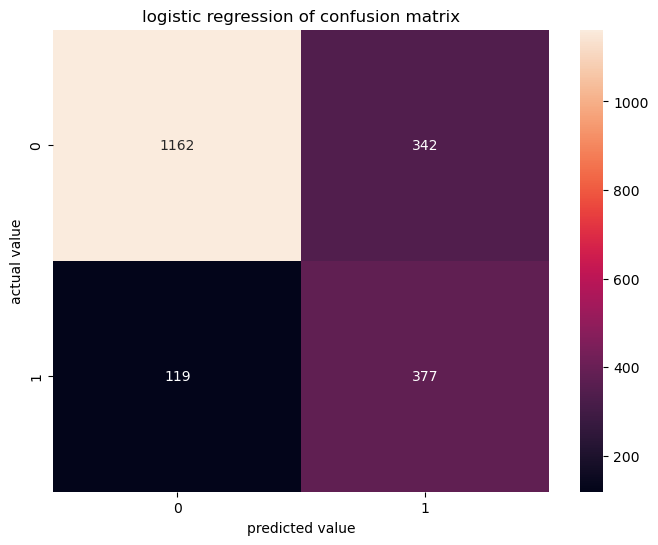

In [47]:
#logistic regression
#1.import algorithm,
from sklearn.linear_model import LogisticRegression

#2.object for class
#model
lr_os=LogisticRegression()

#model training
lr_os.fit(x_train_sampled,y_train_sampled)
print(lr)

#model testing
result_os_lr=lr_os.predict(x_test)
print(result_os_lr)

#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
score_lr_os = accuracy_score(y_test, result_os_lr)
print('Accuracy score of the LR model:', score_lr_os)

# Classification report
cr_lr_os = classification_report(y_test, result_os_lr)
print('Classification Report:\n', cr_lr_os)

# Confusion matrix
import seaborn as sns
cm_lr_os = confusion_matrix(y_test, result_os_lr)
print('Confusion Matrix:\n', cm_lr_os)

plt.figure(figsize=(8,6),dpi=100)
plt.title("logistic regression of confusion matrix")

sns.heatmap(cm_lr_os,annot=True,fmt='d')
plt.xlabel("predicted value")
plt.ylabel("actual value")
plt.show()

[0 1 0 ... 1 0 0]
Accuracy score of the LR model: 0.8535
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86      1504
           1       0.58      0.66      0.62       496

    accuracy                           0.80      2000
   macro avg       0.73      0.75      0.74      2000
weighted avg       0.81      0.80      0.80      2000

Confusion Matrix:
 [[1269  235]
 [ 169  327]]


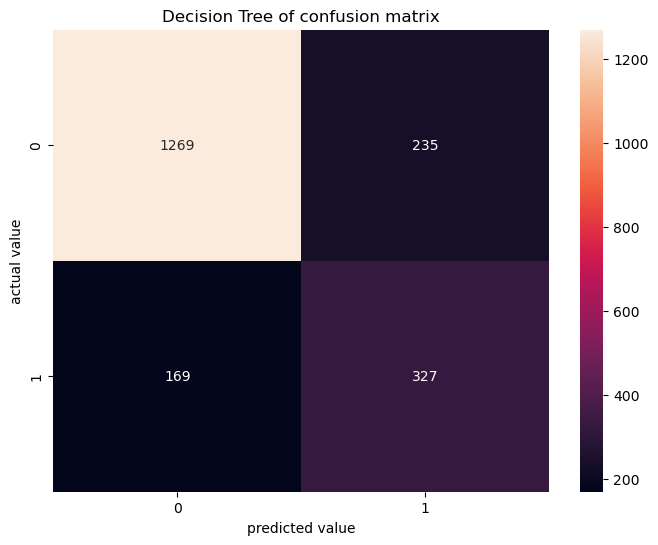

In [48]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
#model building
dt_os=DecisionTreeClassifier()
#model training
dt_os.fit(x_train_sampled,y_train_sampled)
#model testing
result_dt_os=dt_os.predict(x_test)
print(result_dt_os)
#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Calculate accuracy
score_dt_os = accuracy_score(y_test, result)
print('Accuracy score of the LR model:', score_dt_os)

# Classification report
cr_dt_os = classification_report(y_test, result_dt_os)
print('Classification Report:\n', cr_dt_os)

# Confusion matrix
import seaborn as sns
cm_dt_os = confusion_matrix(y_test, result_dt_os)
print('Confusion Matrix:\n', cm_dt_os)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Decision Tree of confusion matrix")

sns.heatmap(cm_dt_os,annot=True,fmt='d')
plt.xlabel("predicted value")
plt.ylabel("actual value")
plt.show()

[0 1 0 ... 0 0 0]
Accuracy score of the LR model: 0.8565
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91      1504
           1       0.76      0.61      0.68       496

    accuracy                           0.86      2000
   macro avg       0.82      0.77      0.79      2000
weighted avg       0.85      0.86      0.85      2000

Confusion Matrix:
 [[1411   93]
 [ 194  302]]


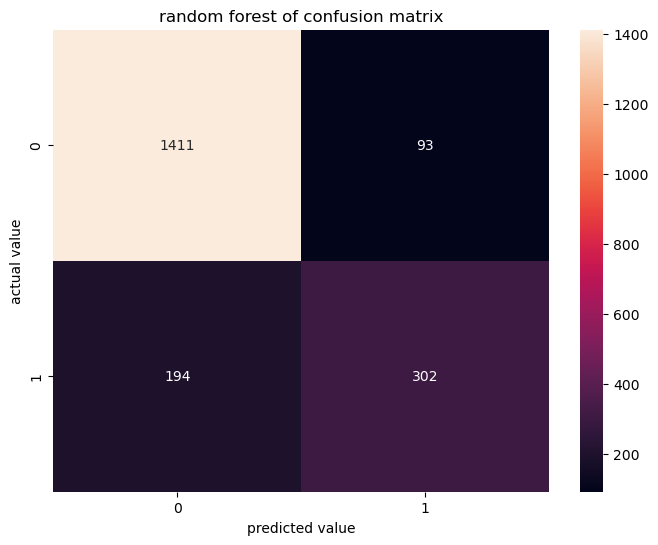

In [49]:
#random forest
from sklearn.ensemble import RandomForestClassifier

#model building
rf_os=RandomForestClassifier()

#model training
rf_os.fit(x_train_sampled,y_train_sampled)

#model testing
result_rf_os=rf_os.predict(x_test)
print(result_rf_os)

#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Calculate accuracy
score_rf_os = accuracy_score(y_test, result_rf_os)
print('Accuracy score of the LR model:', score_rf_os)

# Classification report
cr_rf_os = classification_report(y_test, result_rf_os)
print('Classification Report:\n', cr_rf_os)

# Confusion matrix
import seaborn as sns
cm_rf_os = confusion_matrix(y_test, result_rf_os)
print('Confusion Matrix:\n', cm_rf_os)

plt.figure(figsize=(8,6),dpi=100)
plt.title("random forest of confusion matrix")

sns.heatmap(cm_rf_os,annot=True,fmt='d')
plt.xlabel("predicted value")
plt.ylabel("actual value")
plt.show()

[0 1 0 ... 0 0 0]
Accuracy score of the LR model: 0.835
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89      1504
           1       0.64      0.76      0.70       496

    accuracy                           0.83      2000
   macro avg       0.78      0.81      0.79      2000
weighted avg       0.85      0.83      0.84      2000

Confusion Matrix:
 [[1293  211]
 [ 119  377]]


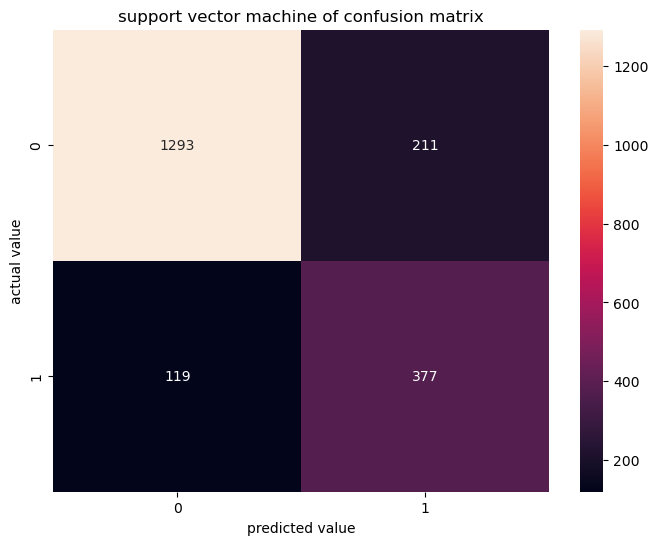

In [50]:
#4.support vector machine
from sklearn.svm import SVC
#model building
svc_os=SVC()
#model training
svc_os.fit(x_train_sampled,y_train_sampled)

#model testing
result_svc_os=svc_os.predict(x_test)
print(result_svc_os)

#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Calculate accuracy
score_svc_os = accuracy_score(y_test, result_svc_os)
print('Accuracy score of the LR model:', score_svc_os)

# Classification report
cr_svc_os= classification_report(y_test, result_svc_os)
print('Classification Report:\n', cr_svc_os)

# Confusion matrix
import seaborn as sns
cm_svc_os = confusion_matrix(y_test, result_svc_os)
print('Confusion Matrix:\n', cm_svc_os)

plt.figure(figsize=(8,6),dpi=100)
plt.title("support vector machine of confusion matrix")

sns.heatmap(cm_svc_os,annot=True,fmt='d')
plt.xlabel("predicted value")
plt.ylabel("actual value")
plt.show()

In [51]:
import joblib

#save LR model
joblib.dump(rf_os,'rf_os_model.pkl')

#save scaler
joblib.dump(scaler,'scaler_ml.pkl')

['scaler_ml.pkl']

In [55]:
print(df.tail())

      Age  Gender   BMI  Medication_Adherence  Number_of_ER_Visits  \
9995   70       0  25.0                  0.67                    0   
9996   78       1  24.8                  0.72                    1   
9997   58       0  30.1                  0.28                    0   
9998   88       1  31.2                  0.44                    0   
9999   13       1  16.4                  0.23                    0   

      Peak_Expiratory_Flow  FeNO_Level  Has_Asthma  Occupation_Type_Indoor  \
9995                 580.6        18.7           0                       1   
9996                 417.6        40.8           0                       1   
9997                 459.1        20.3           1                       1   
9998                 415.9        25.0           0                       1   
9999                 359.4        23.2           1                       0   

      Occupation_Type_Outdoor  ...  Allergies_Pollen  \
9995                        0  ...                 0  

In [ ]:
import pickle
import pandas as pd

#load model and scalar
model=joblib.load("rf_os_model.pkl")
scaler=joblib.load("scaler_ml.pkl")

#create test data with feature names
test_data=pd.DataFrame([[88,0,30.9,0.12,2,303.9,36.8,0,0,1,1,0,1,0,1,1,1,1,1,10,0,1,0,1,0,0,1,0]],columns=['Age', 'Gender', 'BMI', 'Medication_Adherence', 'Number_of_ER_Visits',
       'Peak_Expiratory_Flow', 'FeNO_Level', 'Occupation_Type_Indoor',
       'Occupation_Type_Outdoor', 'Smoking_Status_Current',
       'Smoking_Status_Former', 'Smoking_Status_Never',
       'Physical_Activity_Level_Active', 'Physical_Activity_Level_Moderate',
       'Physical_Activity_Level_Sedentary', 'Allergies_Dust',
       'Allergies_Multiple', 'Allergies_Pets', 'Allergies_Pollen',
       'Air_Pollution_Level_High', 'Air_Pollution_Level_Low',
       'Air_Pollution_Level_Moderate', 'Comorbidities_Both',
       'Comorbidities_Diabetes', 'Comorbidities_Hypertension',
       'Asthma_Control_Level_Not Controlled',
       'Asthma_Control_Level_Poorly Controlled',
       'Asthma_Control_Level_Well Controlled'])
#scaled dat
test_scaled=scaler.transform(test_data)

#predict
prediction=model.predict(test_scaled)

if prediction[0]==1:
    print("high risk of asthma")
else:
    print("low risk of asthma")
    

high risk of asthma


In [58]:
print(x.columns)

Index(['Age', 'Gender', 'BMI', 'Medication_Adherence', 'Number_of_ER_Visits',
       'Peak_Expiratory_Flow', 'FeNO_Level', 'Occupation_Type_Indoor',
       'Occupation_Type_Outdoor', 'Smoking_Status_Current',
       'Smoking_Status_Former', 'Smoking_Status_Never',
       'Physical_Activity_Level_Active', 'Physical_Activity_Level_Moderate',
       'Physical_Activity_Level_Sedentary', 'Allergies_Dust',
       'Allergies_Multiple', 'Allergies_Pets', 'Allergies_Pollen',
       'Air_Pollution_Level_High', 'Air_Pollution_Level_Low',
       'Air_Pollution_Level_Moderate', 'Comorbidities_Both',
       'Comorbidities_Diabetes', 'Comorbidities_Hypertension',
       'Asthma_Control_Level_Not Controlled',
       'Asthma_Control_Level_Poorly Controlled',
       'Asthma_Control_Level_Well Controlled'],
      dtype='object')


In [60]:
print(x.head())

   Age  Gender   BMI  Medication_Adherence  Number_of_ER_Visits  \
0   52       1  27.6                  0.38                    0   
1   15       0  24.6                  0.60                    2   
2   72       1  17.6                  0.38                    0   
3   61       0  16.8                  0.60                    1   
4   21       0  30.2                  0.82                    3   

   Peak_Expiratory_Flow  FeNO_Level  Occupation_Type_Indoor  \
0                 421.0        46.0                       0   
1                 297.6        22.9                       1   
2                 303.3        15.3                       1   
3                 438.0        40.1                       0   
4                 535.0        27.7                       1   

   Occupation_Type_Outdoor  Smoking_Status_Current  ...  Allergies_Pollen  \
0                        1                       0  ...                 0   
1                        0                       0  ...         